# Mixed layer heat budget analysis of ACCESS-OM2 runs

This notebook contains a quick analysis of the mixed layer heat budget in ACCESS-OM2, using online heat budget diagnostics.

## Background Theory and diagnostics

### ACCESS-OM2 "Eulerian" heat budget


\begin{align}
  \textit{temp\_tendency} = &\textit{temp\_advection} + \\ &\quad +
  \textit{temp\_submeso} \\ &\quad + \textit{temp\_vdiffuse\_diff\_cbt}  + \textit{temp\_nonlocal\_KPP} \\ &\quad + \textit{sw\_heat} +
  \textit{temp\_rivermix} + \textit{temp\_vdiffuse\_sbc} + \textit{sfc\_hflux\_pme} \\
  & \quad + \textit{frazil\_3d}\\ 
   & \quad + \textit{temp\_vdiffuse\_k33} + \textit{neutral\_diffusion\_temp}\\
   & \quad + \textit{neutral\_gm\_temp} \\
   & \quad + \textit{mixdownslope\_temp} + \textit{temp\_sigma\_diff} + \textit{temp\_eta\_smooth}
\end{align}

All terms are in units of Wm$^{-2}$ - i.e. the tendency of the heat content within each grid cell per unit area, $\rho_0 C_p\Theta \Delta z$, where $\Delta z$ is the time variable grid cell thickness, $\rho_0=1035$kgm$^{-3}$ is the reference density, $C_p=3992.10322329649$Jkg$^{-1}$$^\circ$C$^{-1}$ is the specific heat and $\Theta$ is Conservative Temperature.

- temp\_tendency is the tendency term
- temp\_advection is the convergence of the three-dimensional resolved advection (this can be split into components by taking the convergence of the temp\_xflux\_adv, temp\_yflux\_adv and temp\_zflux\_adv terms)
- temp\_submeso is the convergence of the three-dimensional parameterized submesoscale advection (pretty small).
- temp\_vdiffuse\_diff\_cbt and temp\_nonlocal\_KPP are the vertical mixing terms.
- The next line contains all of the surface heat flux terms. Note that sw\_heat is a three-dimensional term that *redistributes* the impact of SW radiation from the surface layer into the interior (i.e. it is negative in the surface layer and positive below, summing to zero). temp\_rivermix is also three-dimensional as the impact of river runoff is spread over a few layers (4 I think). The other terms are two-dimensional (only non-zero in the surface layer).
- frazil\_3d is the formation of frazil ice
- temp\_vdiffuse\_k33 and neutral\_diffusion\_temp are parameterized along-isopycnal mixing (might not be on in all configurations, e.g. ACCESS-OM2-01).
- neutral\_gm\_temp is parameterization advection by mesoscale eddies
- The last line includes some miscellaneous mixing terms (all pretty small).

Also see https://github.com/COSIMA/access-om2/issues/139#issuecomment-639278547 for a discussion of the surface heat flux terms in ACCESS-OM2/CM2.

### Mixed layer temperature budget 

At each grid cell write the model heat budget above as

$$\frac{\partial (\rho_0 C_p \Theta \Delta z)}{\partial t} = \textit{temp\_tendency} = \sum_i P_i$$

Where $P_i$ are the RHS processes. Units are Wm$^{-2}$. Summing (where we use an integral sign for simplicity) over a mixed layer of depth $MLD(x,y,t)$ gives

$$\int_{-MLD}^\eta \frac{\partial (\rho_0 C_p \Theta \Delta z)}{\partial t} = \int_{-MLD}^\eta \sum_i P_i$$

Using a Leibniz rule for the LHS gives

$$\frac{\partial}{\partial t} \int_{-MLD}^\eta (\rho_0 C_p \Theta \Delta z) - \frac{\partial MLD}{\partial t}\rho_0 C_p \Theta_{ent} = \int_{-MLD}^\eta \sum_i P_i$$

Where $\Theta_{ent}=\Theta(x,y,z=MLD,t)$ is the temperature at the base of the mixed layer. Setting $\int_{-MLD}^\eta (\rho_0 C_p \Theta \Delta z) = \rho_0 C_p \Theta_{MLD} MLD$, where $\Theta_{MLD}$ is the mixed layer average temperature. We thus have:
\begin{align*}
    \frac{\partial (\rho_0 C_p \Theta_{MLD} MLD)}{\partial t} - \frac{\partial MLD}{\partial t}\rho_0 C_p \Theta_{ent} &= \int_{-MLD}^\eta \sum_i P_i \\
    \Longrightarrow \frac{\partial \Theta_{MLD}}{\partial t} + \frac{1}{MLD}\frac{\partial MLD}{\partial t}\left(\Theta_{MLD} - \Theta_{ent}\right) &= \frac{1}{\rho_0 C_p MLD}\int_{-MLD}^\eta \sum_i P_i
\end{align*}

This forms a budget for the tendency of the temperature averaged over the mixed layer (effectively, the SST), where the first term on the LHS is the mixed layer temperature tendency, the second term is the entrainment term and the RHS terms are as before. 

This calculation shows that the entrainment term is not an explicit diagnostic in ACCESS-OM2. However, the above equation suggests a method to compute it. I.e. one could compute a closed budget by computing the mixed layer temperature tendency offline (for full accuracy this should be done with *snapshots* of the temperature rather than time averages) and then computing the entrainment term as a residual from the integral of temp\_tendency over the mixed layer (the LHS of the above equation, divided by MLD). I.e.

$$\frac{1}{MLD}\frac{\partial MLD}{\partial t}\left(\Theta_{MLD} - \Theta_{ent}\right) =  - \frac{\partial \Theta_{MLD}}{\partial t} + \frac{1}{\rho_0 C_p MLD} \int_{-MLD}^\eta temp\_tendency$$

Note: Kim et al. (2006, https://doi.org/10.1175/JTECH1883.1) also describe a method to compute the entrainment term exactly that, I think, is equivalent to what I've done above.

Of course, while it is a closed budget, it's not exactly a budget of the mixed layer temperature because of the averaging time-scale of the diagnostics (e.g. with daily average diagnostics, the terms don't account for subdaily correlations). But it shouldn't be far off. The computations below test this assumption by comparing daily and monthly averaged diagnostics (although the saving of daily averaged diagnostics over a long simulation is rather impractical).

It could be made an exact budget of the mixed layer temperature if code was added to the ACCESS-OM2 code base to integrate the heat budget diagnostics over the mixed layer depth at every time step. If this were done, the resulting diagnostics would be two-dimensional and so could easily be saved at daily resolution if sub-monthly information on how the various terms vary was wanted (or just save the exact monthly averages).

I believe that it is easier to work with the mixed layer temperature budget (as written above), rather than a mixed layer heat content budget, because it is easier to avoid errors associated with mismatches between budget terms and MLD/grid-cell thicknesses. The mixed layer temperature varies much more smoothly with time than the mixed layer heat content (i.e. as the mixed layer depth varies).

In [1]:
#Load required packages
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import cftime

import cmocean as cm
import sys, os

from dask.distributed import Client

In [2]:
# Load workers:
client = Client(n_workers=28)
client

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37665 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/37665/status,
Dashboard: /proxy/37665/status,Workers: 28
Total threads: 28,Total memory: 125.18 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33979,Workers: 28
Dashboard: /proxy/37665/status,Total threads: 28
Started: Just now,Total memory: 125.18 GiB
Comm: tcp://127.0.0.1:43019,Total threads: 1
Dashboard: /proxy/38577/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:37893,


In [3]:
# Chdir for figure saving:
os.chdir('access-om2-analysis/access-om2-sst-budget')

## Load datasets:

In [4]:
# base = '/g/data/ik11/outputs/access-om2-025/025deg_jra55_iaf_omip2_cycle6_jra55v150_extension/'
base = '/scratch/v45/rmh561/access-om2/archive/025deg_jra55_iaf/'
output = 371
base2 = base + 'output%03d/ocean/' % output

reg = [-100, 20, 0, 60]

In [33]:
# monthly data:
ds_month = xr.open_dataset(base2 + 'ocean_month.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_grid = xr.open_dataset(base2 + 'ocean_grid.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_budget = xr.open_dataset(base2 + 'ocean_budget.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))

# Add snapshot from previous output:
ds_snapshot = xr.open_dataset(base2 + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_snapshot_m1 = xr.open_dataset(base2.replace(str(output),str(output-1)) + 'ocean_snapshot.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_snapshot = xr.concat([ds_snapshot_m1.isel(time=-1),ds_snapshot],dim='time')

In [35]:
# daily data:
ds_budget_daily = xr.open_dataset(base2 + 'ocean_budget_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_daily = xr.open_dataset(base2 + 'ocean_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))

# Add snapshot from previous output:
ds_snapshot_daily = xr.open_dataset(base2 + 'ocean_snapshot_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_snapshot_daily_m1 = xr.open_dataset(base2.replace(str(output),str(output-1)) + 'ocean_snapshot_daily.nc').sel(xt_ocean=slice(reg[0],reg[1]),yt_ocean=slice(reg[2],reg[3]))
ds_snapshot_daily = xr.concat([ds_snapshot_daily_m1.isel(time=-1),ds_snapshot_daily],dim='time')

# NOTE: THere is some bug with the time variable in the daily data - it is offset by a few days. 
# Doesn't make a difference for the below calculations (since I'm averaging over all four months).
# However, important to be aware of.

## Define function to compute mixed layer temperature budget

In [44]:
def compute_mixed_layer_temperature_budget(ds_budget,pot_rho_0,dzt,ds_snapshot):
    """
    Compute mixed layer temperature budget

    Inputs:
    ds_budget -> dataset containing time-averaged budget quantities
    pot_rho_0 -> dataarray containing time-averaged surface referenced potential density for MLD calculation
    dzt       -> dataarray containing time-averaged grid-cell thicknesses for MLD calculation
    ds_snapshot -> dataset containing snapshots of temperature, dzt and pot_rho_0 for mixed layer temperature tendency computation

    Outputs:
    budget -> dataset containing all the terms in the diagnosed mixed layer temperature budget
    """
    
    rho0 = 1035.
    Cp = 3992.10322329649
    
    bud_vars = ['temp_tendency','temp_advection','temp_submeso','temp_vdiffuse_diff_cbt','temp_nonlocal_KPP',
            'temp_vdiffuse_sbc','frazil_3d','neutral_diffusion_temp','neutral_gm_temp',
            'temp_vdiffuse_k33','neutral_diffusion_temp','neutral_gm_temp','sw_heat','temp_rivermix']
    budget = ds_budget[bud_vars]

    # Sum over mixed layer:
    mld = dzt.where(pot_rho_0 - pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean') # mixed layer depth
    budget = budget.where(pot_rho_0 - pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean') # Budget summed over mixed layer
    budget = budget/rho0/Cp/mld                                                     # Convert units to degC s-1

    # Add 2D surface layer variables:
    budget['temp_eta_smooth'] = ds_budget['temp_eta_smooth']/rho0/Cp/mld
    budget['sfc_hflux_pme'] = ds_budget['sfc_hflux_pme']/rho0/Cp/mld

    # Compute residual for check:
    budget['residual'] = budget['temp_tendency'].copy()
    for var in budget.data_vars:
        budget['residual'] -= budget[var]

    # Compute mixed layer temperature tendency and entrainment term

    # mixed layer temperature from snapshots:
    mld_snap = ds_snapshot.dzt.where(ds_snapshot.pot_rho_0 - ds_snapshot.pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean') # mixed layer depth
    mlt_snap = (ds_snapshot.dzt*(ds_snapshot.temp-273.15)).where(ds_snapshot.pot_rho_0 - ds_snapshot.pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean')
    mlt_snap = mlt_snap/mld_snap                                                                                             # mixed layer temperature (deg C)
    
    # mixed layer temperature tendency:
    budget['mlt_tendency'] = budget['temp_tendency'].copy()
    shape = budget.temp_tendency.shape
    budget['mlt_tendency'].data = np.transpose(mlt_snap.isel(time=slice(1,None)).values - mlt_snap.isel(time=slice(0,-1)).values,(2, 0, 1))
    budget['mlt_tendency'] = budget['mlt_tendency']/(ds_budget.average_DT / np.timedelta64(1, 's'))

    # Entrainment term by residual:
    budget['entrainment'] = -(budget['temp_tendency'] - budget['mlt_tendency'])

    return(budget)

## Do computations

In [45]:
# Compute monthly budget:

# Add a few terms that are in ds_month in the monthly output:
ds_budget['sw_heat'] = ds_month['sw_heat']
ds_budget['sfc_hflux_pme'] = ds_month['sfc_hflux_pme']
ds_budget['temp_rivermix'] = ds_month['temp_rivermix']

mon_budget_temp = compute_mixed_layer_temperature_budget(ds_budget,ds_month.pot_rho_0,ds_month.dht,ds_snapshot)

# Save to file:
mon_budget_temp.to_netcdf('/g/data/dx2/rmh561/mon_budget_temp_om2_omip2_extension_output371.nc')

In [5]:
# Load from file:
mon_budget_temp = xr.open_dataset('/g/data/dx2/rmh561/mon_budget_temp_om2_omip2_extension_output371.nc')

0.3.0


In [ ]:
%%time
# Compute daily budget:
day_budget_temp = compute_mixed_layer_temperature_budget(ds_budget_daily,ds_daily.pot_rho_0,ds_daily.dzt,ds_snapshot_daily)

# Save to file:
day_budget_temp.to_netcdf('/g/data/dx2/rmh561/day_budget_temp_om2_omip2_extension_output371.nc')

In [6]:
# Load from file:
day_budget_temp = xr.open_dataset('/g/data/dx2/rmh561/day_budget_temp_om2_omip2_extension_output371.nc')

## Do some plotting

#### Spatial plots of all terms:

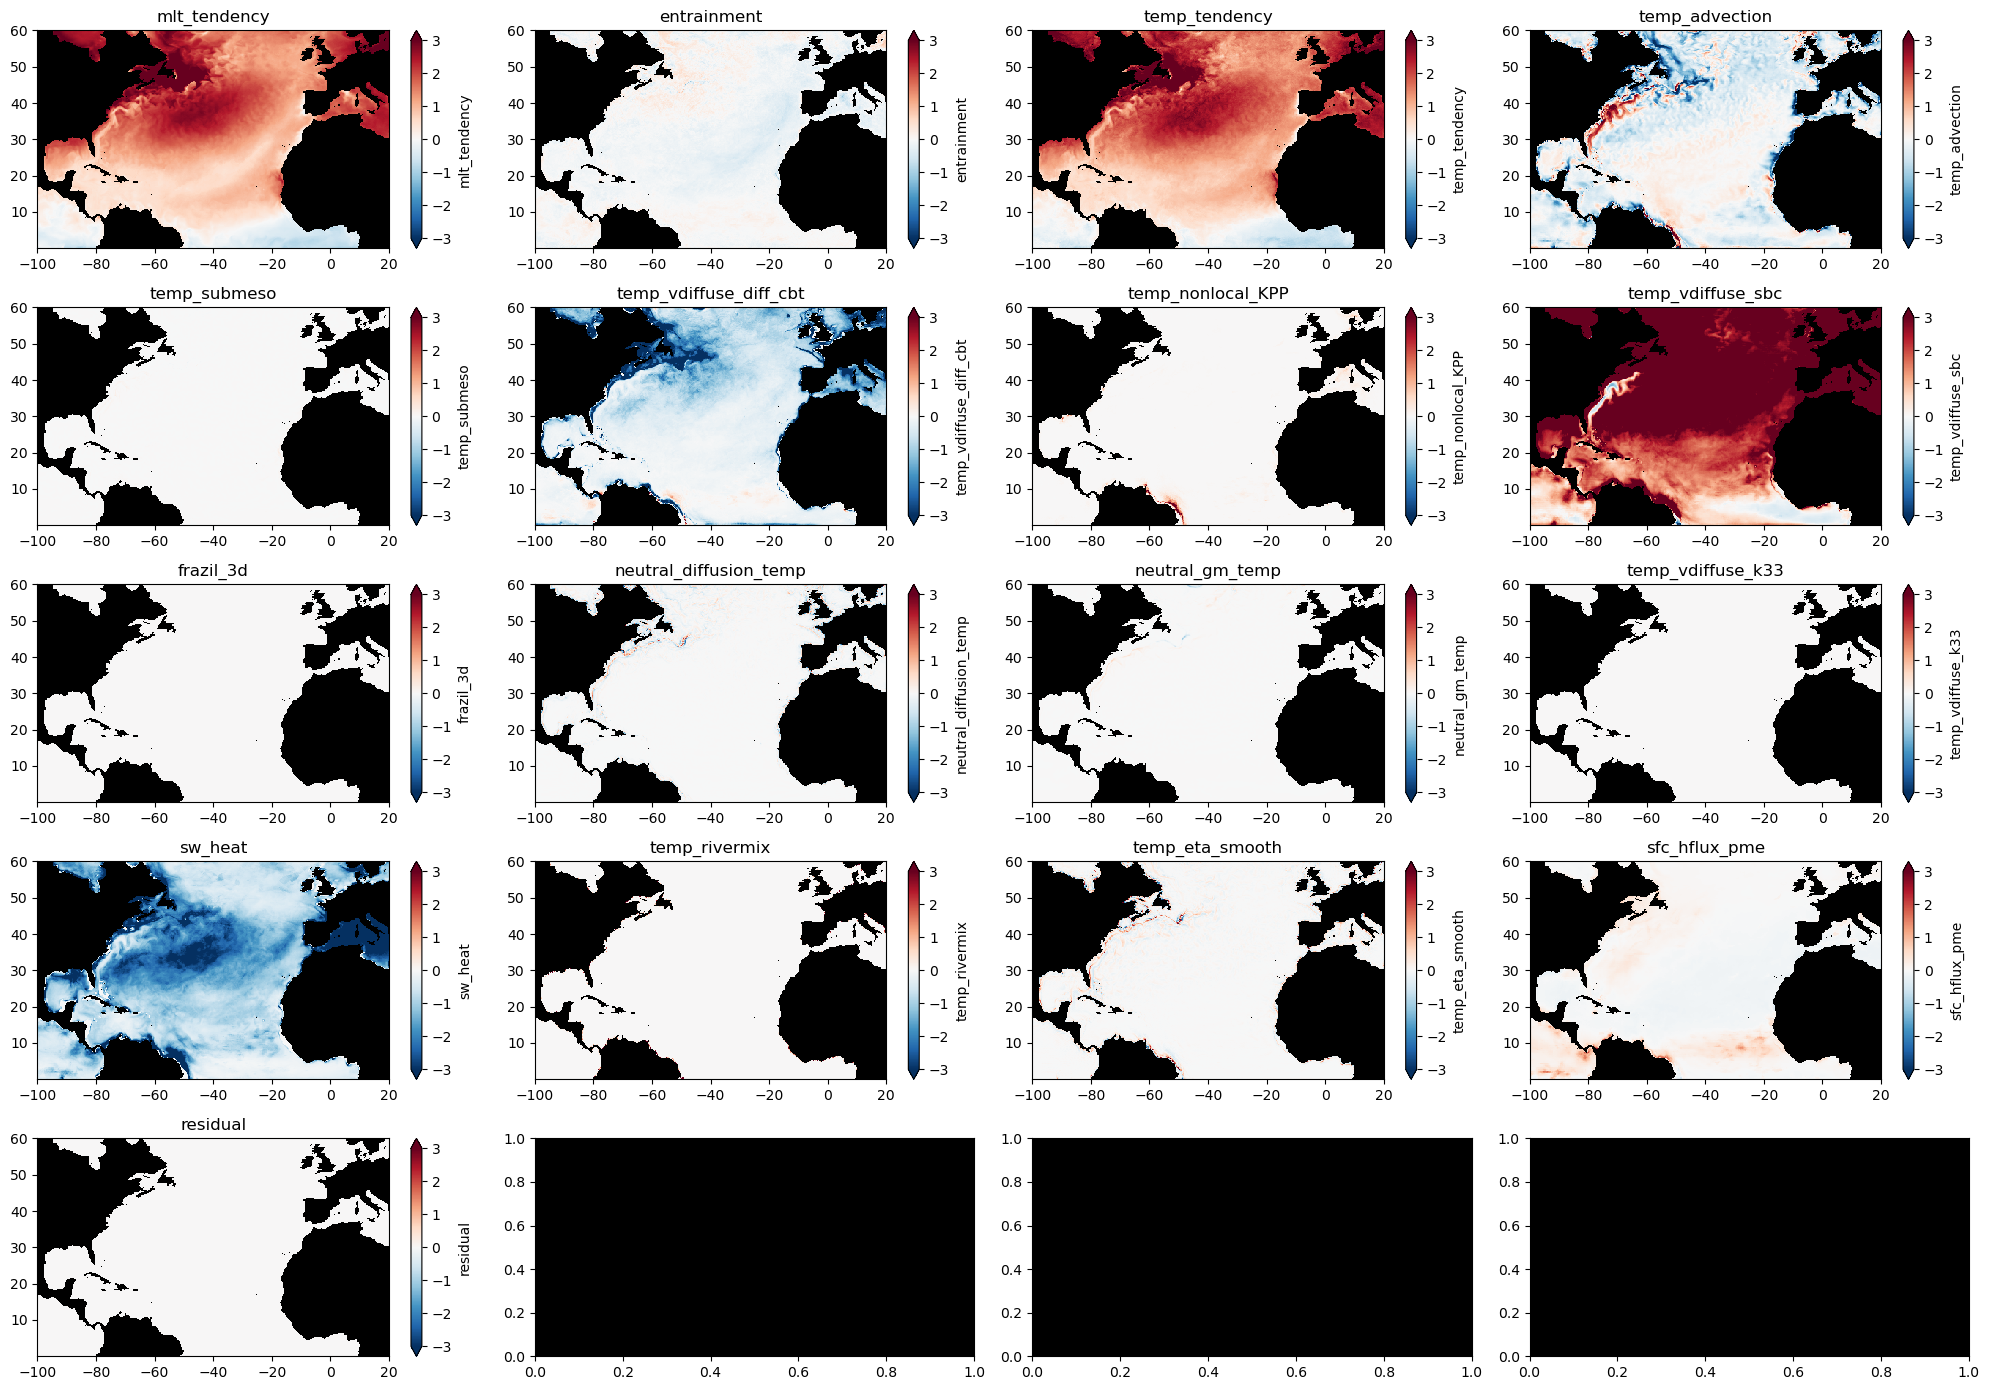

In [57]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20,14))
axs = axes.reshape(-1)

# Select budget and convert units
#budget = mon_budget_temp.mean('time')*86400*30.5 # Average May-July and convert from degC s-1 to degC/month
budget = day_budget_temp.mean('time')*86400*30.5 # Average May-July and convert from degC s-1 to degC/month

vars = list(budget.data_vars)
vars.remove('entrainment');vars.insert(0,'entrainment');vars.remove('mlt_tendency');vars.insert(0,'mlt_tendency');

clim = 3.
for i, var in enumerate(vars):
    budget[var].plot(ax=axs[i],cmap='RdBu_r',vmin=-clim,vmax=clim,extend='both')#,vmax=0.001)#vmin=-0.1,vmax=0.1) 
    axs[i].set_title(var)
# Note: Make the color limits much smaller and look at "residual" to see that it closes. Although, of course, you can't 
# check that the mlh_tendency and entrainment calculations close since they are done by residual.

for ax in axs:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('k')
plt.tight_layout()
plt.savefig('daily_ml_temperature_budget_Atlantic_May_to_Aug_2023_allterms.png',dpi=150)

#### Spatial plots of just the main terms:

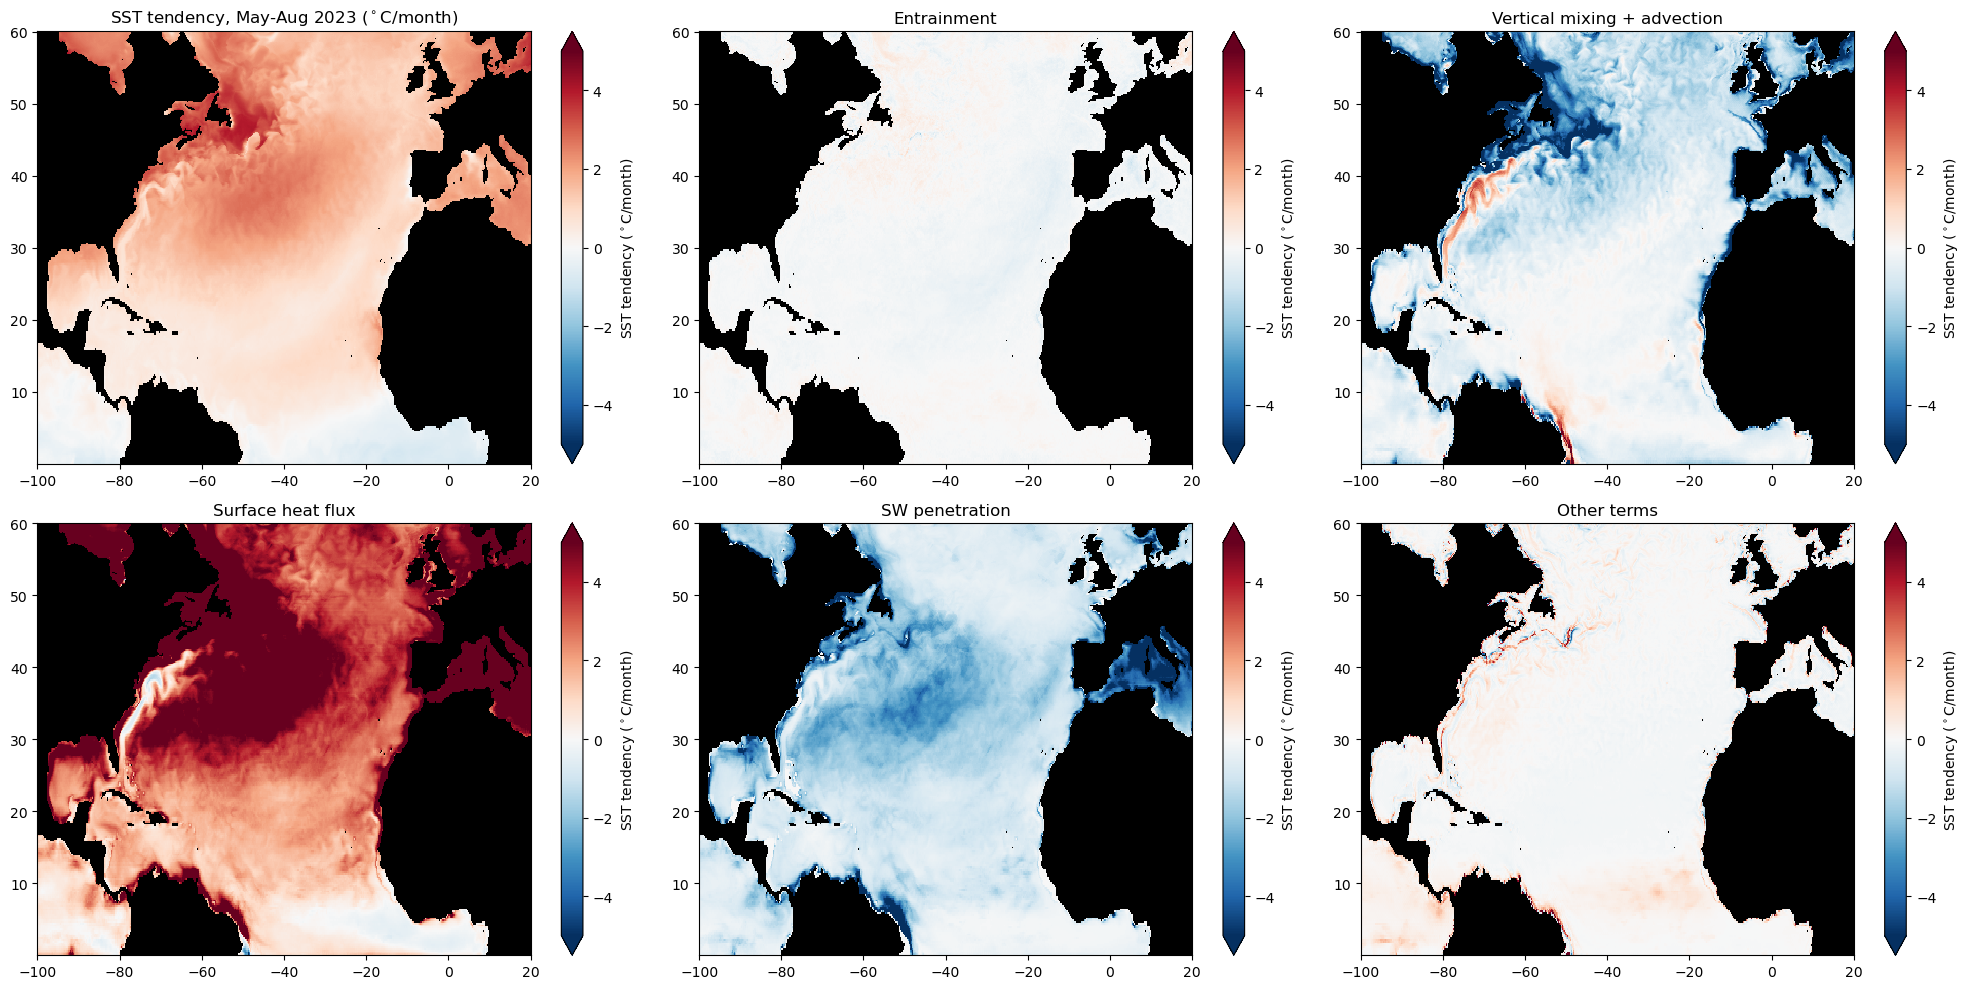

In [62]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20,10))
axs = axes.reshape(-1)

# Select budget and convert units
#budget = mon_budget_temp*86400*30.5 # Convert from degC s-1 to degC/month
budget = day_budget_temp*86400*30.5 # Convert from degC s-1 to degC/month

budget['vertical_mixing'] = budget['temp_vdiffuse_diff_cbt']+budget['temp_nonlocal_KPP']
budget['ocean_dynamics'] = budget['vertical_mixing']+budget['temp_advection']

vars = ['mlt_tendency','entrainment','ocean_dynamics','temp_vdiffuse_sbc','sw_heat','other_terms']
names = ['SST tendency, May-Aug 2023 ($^\circ$C/month)','Entrainment','Vertical mixing + advection','Surface heat flux','SW penetration','Other terms']
budget['other_terms'] = budget['mlt_tendency'].copy()
for var in vars[1:-1]:
    budget['other_terms'] -= budget[var]

# Average May-Aug:
budget_tavg = budget.mean('time')
for i, var in enumerate(vars):
    budget_tavg[var].plot(ax=axs[i],vmin=-5.,vmax=5.,cmap='RdBu_r', cbar_kwargs={'label':'SST tendency ($^\circ$C/month)'},extend='both')
    axs[i].set_title(names[i])

for ax in axs:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('k')
plt.tight_layout()
plt.savefig('daily_ml_temperature_budget_Atlantic_May_to_Aug_2023_mainterms.png',dpi=150)

#### area averaged plots:

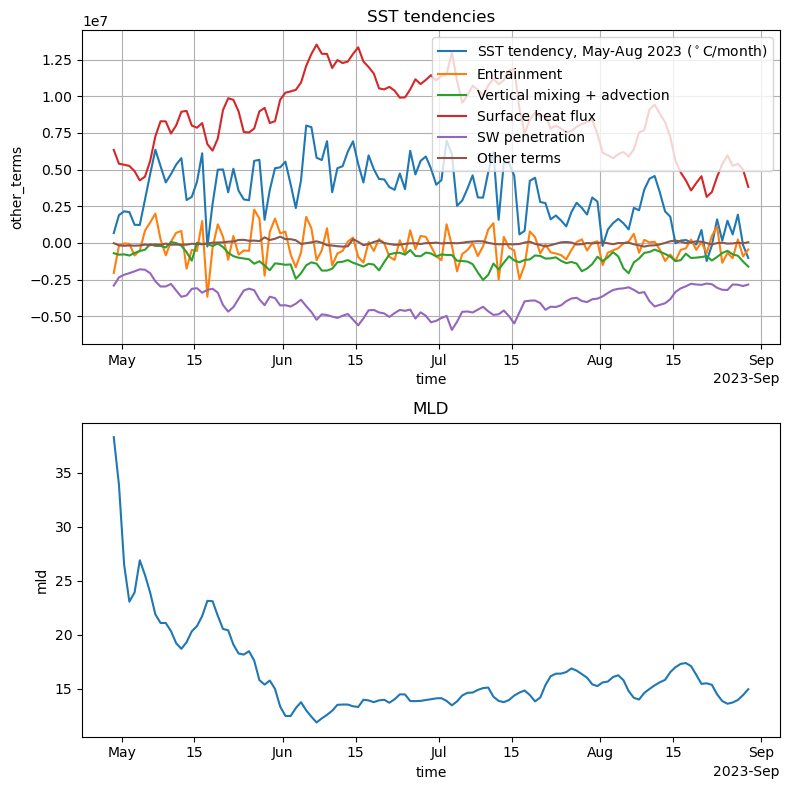

In [63]:
budget_temp_areaavg = (budget*86400*30.5).sel(xt_ocean=slice(-80.,-20.),yt_ocean=slice(10.,40.)).mean('xt_ocean').mean('yt_ocean')

fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(8,8))

for i, var in enumerate(vars):
    budget_temp_areaavg[var].plot(ax=axes[0],label=names[i])
axes[0].legend()
axes[0].grid()
axes[0].set_title('SST tendencies')

ds_daily.mld.sel(xt_ocean=slice(-80.,-20.),yt_ocean=slice(10.,40.)).mean('xt_ocean').mean('yt_ocean').plot(ax=axes[1])
axes[1].set_title('MLD')
plt.tight_layout()
plt.savefig('daily_ml_temperature_budget_Atlantic_mainterms_time_series.png',dpi=150)

#### Quantitative comparison of monthly and daily-averaged diagnostics:

In [36]:
# Extract main terms and area average:
budgets = [day_budget_temp,mon_budget_temp]
for i in range(2):

    budget = budgets[i].copy()

    budget['vertical_mixing'] = budget['temp_vdiffuse_diff_cbt']+budget['temp_nonlocal_KPP']
    budget['ocean_dynamics'] = budget['vertical_mixing']+budget['temp_advection']
    
    vars = ['mlt_tendency','entrainment','ocean_dynamics','temp_vdiffuse_sbc','sw_heat','other_terms']
    names = ['SST tendency, May-Aug 2023 ($^\circ$C/month)','Entrainment','Vertical mixing + advection','Surface heat flux','SW penetration','Other terms']
    budget['other_terms'] = budget['mlt_tendency'].copy()
    for var in vars[1:-1]:
        budget['other_terms'] -= budget[var]
    budget = budget[vars]

    budget = (budget*86400*30.5).sel(xt_ocean=slice(-80.,-20.),yt_ocean=slice(10.,40.)).mean('xt_ocean').mean('yt_ocean')
    budgets[i] = budget.copy()

day_budget_main = budgets[0]
mon_budget_main = budgets[1]

day_budget_main_mon = 0*mon_budget_main.copy()
for var in day_budget_main_mon.data_vars:
    day_budget_main_mon[var][0] = day_budget_main[var].isel(time=slice(0,31)).mean('time')
    day_budget_main_mon[var][1] = day_budget_main[var].isel(time=slice(31,61)).mean('time')
    day_budget_main_mon[var][2] = day_budget_main[var].isel(time=slice(61,92)).mean('time')
    day_budget_main_mon[var][3] = day_budget_main[var].isel(time=slice(92,None)).mean('time')

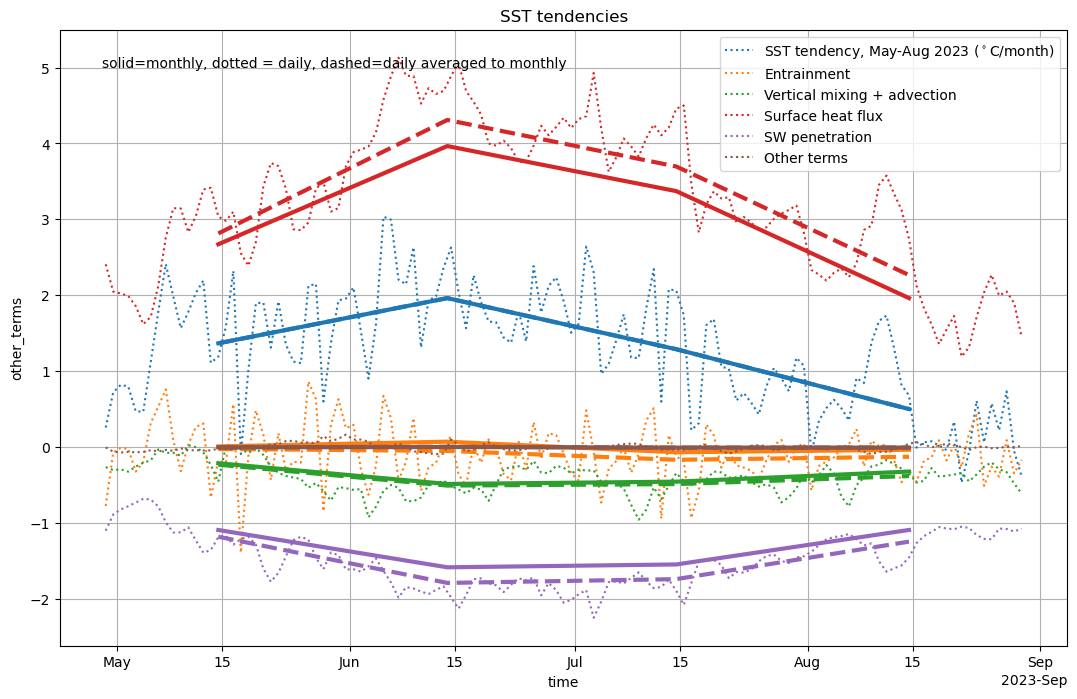

In [50]:
# area averaged plots:
fig = plt.figure(figsize=(13,8))
for i, var in enumerate(vars):
    day_budget_main[var].plot(label=names[i],color='C' + str(i),linestyle='dotted')
    mon_budget_main[var].plot(color='C' + str(i),linestyle='-',linewidth=3.)
    day_budget_main_mon[var].plot(color='C' + str(i),linestyle='--',linewidth=3.)
plt.legend()
plt.grid()
plt.title('SST tendencies')
plt.text(np.datetime64('2023-04-29'),5.,'solid=monthly, dotted = daily, dashed=daily averaged to monthly')

#ds_daily.mld.sel(xt_ocean=slice(-80.,-20.),yt_ocean=slice(10.,40.)).mean('xt_ocean').mean('yt_ocean').plot(ax=axes[1])
#ds_monthly.mld.sel(xt_ocean=slice(-80.,-20.),yt_ocean=slice(10.,40.)).mean('xt_ocean').mean('yt_ocean').plot(ax=axes[1])
#axes[1].set_title('MLD')
#plt.tight_layout()
# plt.savefig('daily_ml_temperature_budget_Atlantic_mainterms_time_series.png',dpi=150)
plt.savefig('Daily_Monthly_area_averaged_comparison.png')

### Old code below here

Mainly, this just contains attempts at deriving the budget using a mixed layer *heat content* approach, rather than a mixed layer *temperature* approach. 

I ended up going for the mixed layer *temperature* approach because, I think, it is smoother and less subject to the potential for errors coming from mismatching the tendency terms with grid cell thickness and MLD measures. E.g. you're always working with volume averaged quantities, rather than volume integrated quantities.

In [8]:
# Compute monthly budget:

# Add a few terms that are in ds_month in the monthly output:
ds_budget['sw_heat'] = ds_month['sw_heat']
ds_budget['sfc_hflux_pme'] = ds_month['sfc_hflux_pme']
ds_budget['temp_rivermix'] = ds_month['temp_rivermix']

mon_budget = compute_mixed_layer_heat_budget(ds_budget,ds_month.pot_rho_0,ds_snapshot.dzt,ds_snapshot)

# Convert units (from Wm-2 into degC/30.5 days) and mask land:
budget_temp = budget.where(~np.isnan(ds_budget.temp_tendency.isel(time=0,st_ocean=0)))/rho0/Cp/ds_month.mld*86400*30.5

In [17]:
# Define a function to compute the budget terms (for either daily or monthly):
rho0 = 1035.
Cp = 3992.10322329649

def compute_mixed_layer_heat_budget(ds_budget,pot_rho_0,dzt,ds_snapshot):
    
    bud_vars = ['temp_tendency','temp_advection','temp_submeso','temp_vdiffuse_diff_cbt','temp_nonlocal_KPP',
            'temp_vdiffuse_sbc','frazil_3d','neutral_diffusion_temp','neutral_gm_temp',
            'temp_vdiffuse_k33','neutral_diffusion_temp','neutral_gm_temp','sw_heat','temp_rivermix']
    budget = ds_budget[bud_vars]

    # Sum over mixed layer:
    budget = budget.where(pot_rho_0 - pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean')

    # Add 2D variables:
    budget['temp_eta_smooth'] = ds_budget['temp_eta_smooth']
    budget['sfc_hflux_pme'] = ds_budget['sfc_hflux_pme']

    # Compute residual for check:
    budget['residual'] = budget['temp_tendency'].copy()
    for var in budget.data_vars:
        budget['residual'] -= budget[var]

    # Compute offline MLD heat content tendency from snapshots:

    # mixed layer heat content from snapshots:
    mlh_snap = (rho0*Cp*dzt*(ds_snapshot.temp-273.15)).where(ds_snapshot.pot_rho_0 - ds_snapshot.pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean')

    # mixed layer heat content tendency:
    budget['mlh_tendency'] = budget['temp_tendency'].copy()
    budget['mlh_tendency'].data = mlh_snap.isel(time=slice(1,None)).values - mlh_snap.isel(time=slice(0,-1)).values
    budget['mlh_tendency'] = budget['mlh_tendency']/(ds_budget.average_DT / np.timedelta64(1, 's'))

    # Entrainment term by residual:
    budget['entrainment'] = -(budget['temp_tendency'] - budget['mlh_tendency'])

    return(budget)

#### Compare ML-averaged temperature tendency to SST tendency:

In [64]:
SST_tendency = xr.zeros_like(ds_budget.temp_tendency.isel(st_ocean=0))
SST_tendency.data = ds_snapshot.temp.isel(st_ocean=0,time=slice(1,None)).values - ds_snapshot.temp.isel(st_ocean=0,time=slice(0,-1)).values
SST_tendency = (SST_tendency/(ds_month.average_DT / np.timedelta64(1, 's')))*86400*30.5

In [68]:
mlh_snap = (rho0*Cp*ds_snapshot.dzt*(ds_snapshot.temp-273.15)).where(ds_snapshot.pot_rho_0 - ds_snapshot.pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean')
mld_snap = ds_snapshot.dzt.where(ds_snapshot.pot_rho_0 - ds_snapshot.pot_rho_0.isel(st_ocean=0) < 0.125).sum('st_ocean')

mlt_snap = mlh_snap/rho0/Cp/mld_snap

In [69]:
mlt_tendency = xr.zeros_like(ds_budget.temp_tendency.isel(st_ocean=0))
mlt_tendency.data = mlt_snap.isel(time=slice(1,None)).values - mlt_snap.isel(time=slice(0,-1)).values
mlt_tendency = (mlt_tendency/(ds_month.average_DT / np.timedelta64(1, 's')))*86400*30.5

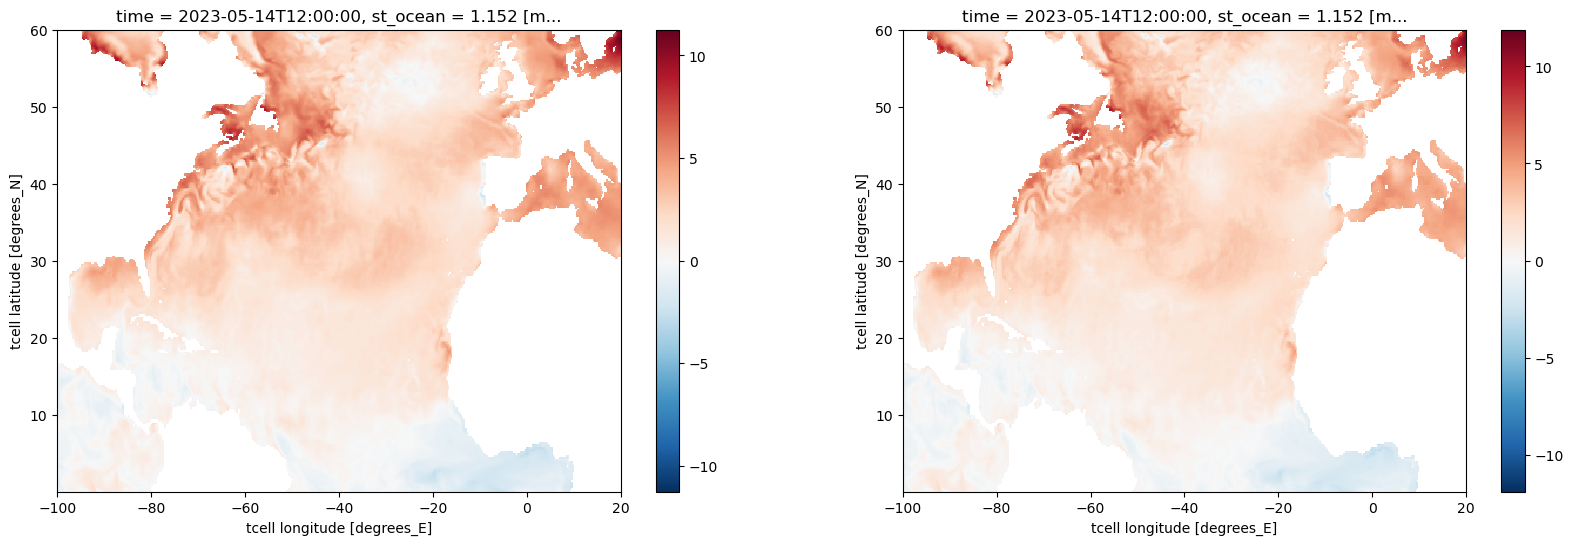

In [72]:
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(20,6))

SST_tendency.isel(time=0).plot(ax=axes[0])
mlt_tendency.isel(time=0).plot(ax=axes[1])